First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HighValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,1
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,1
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,1
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,1
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,1



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HighValue   20640 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 1.4 MB

Summary Statistics:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HighValue
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,0.500242
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,0.500012
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.000000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,0.000000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.000000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,1.000000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,1.000000


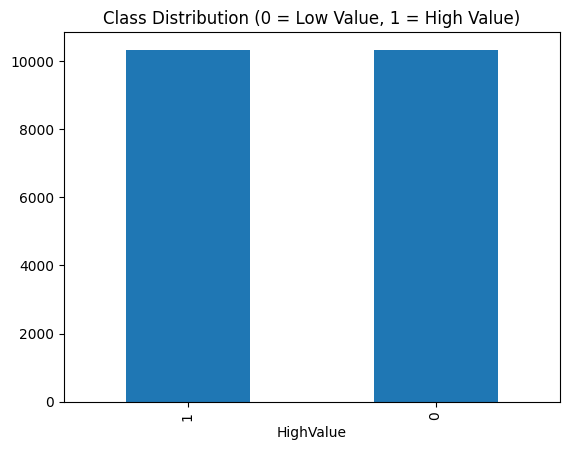

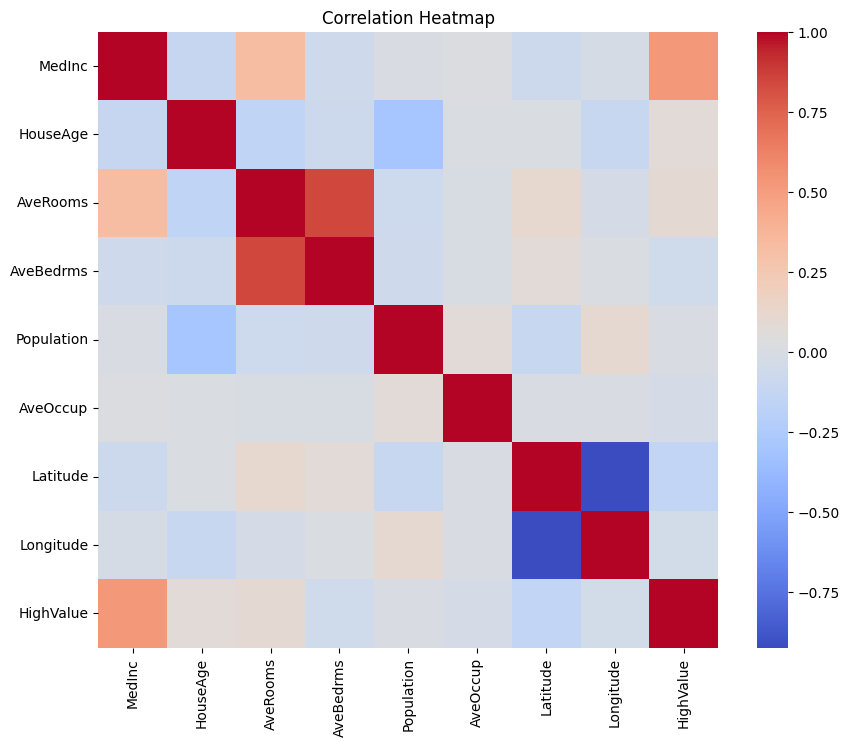

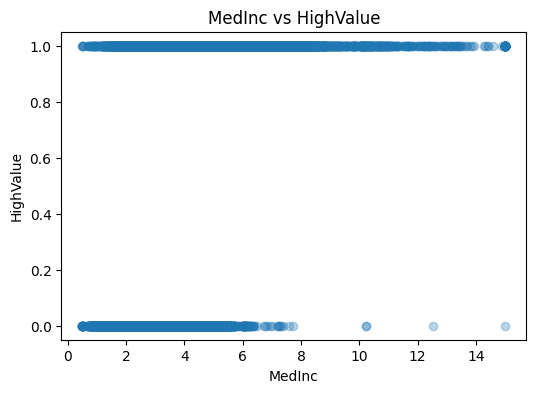

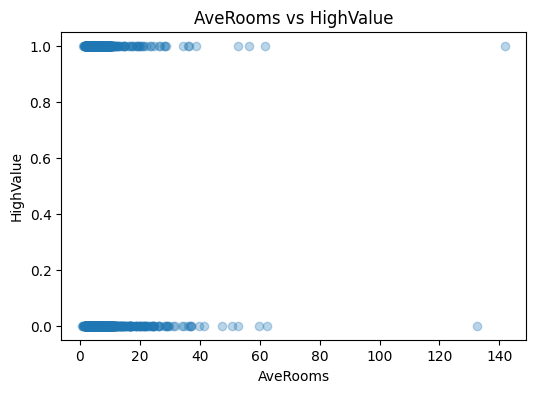

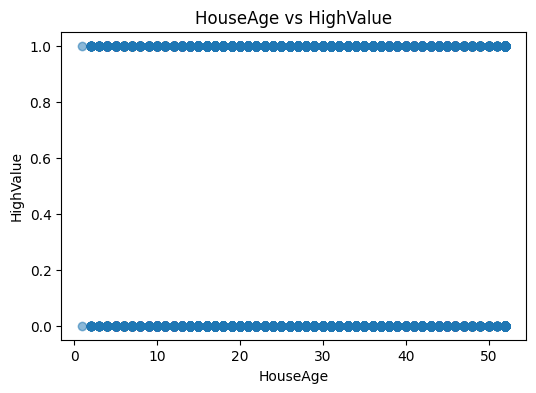


Model Performance Summary:


,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.824855,0.823673,0.824074,0.823873,0.907829
Decision Tree,0.842054,0.837187,0.846979,0.842054,0.842083
Random Forest,0.894138,0.899555,0.885965,0.892708,0.958802
KNN,0.830669,0.827921,0.832359,0.830134,0.903841
SVM,0.860223,0.861342,0.856725,0.859028,0.935456



Best Model Based on ROC-AUC: Random Forest


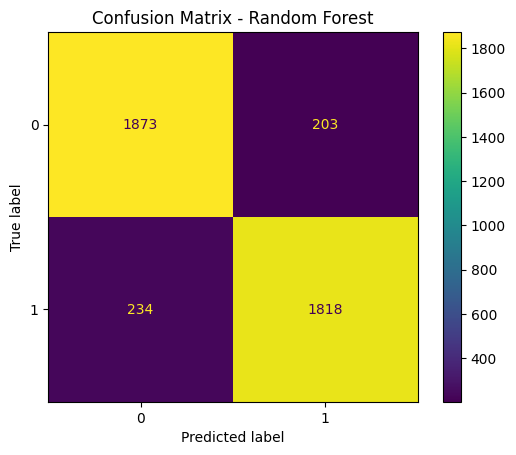

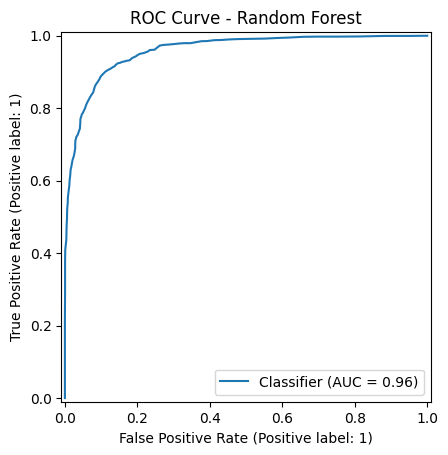


Deployment Strategy:
1. Save the trained best model using joblib or pickle.
2. Deploy it as a REST API using FastAPI or Flask.
3. Host the API on Azure, AWS, or Google Cloud.
4. Connect the API to a real-time data pipeline.
5. Build a simple UI or integrate with a web app.

Monitoring Strategy:
1. Track model accuracy and drift over time.
2. Monitor input data quality.
3. Retrain the model periodically with new data.
4. Log predictions and errors for auditing.
5. Set alerts for performance drops.


TWO-PAGE REPORT SUMMARY

1. Introduction
This project uses the California Housing dataset to classify homes into
high-value and low-value categories. The goal is to build and evaluate
multiple classification models and determine the best-performing one.

2. Data Preprocessing & EDA
- Converted regression target into binary classes.
- No missing values were found.
- Removed duplicates.
- Correlation analysis showed strong relationships between MedInc and home value.
- Scatter plots revealed 

In [2]:
# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC


# --- Dataset Loading ---
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['MedHouseVal'] = data.target


# --- Convert Regression Target → Classification Target ---
median_value = df['MedHouseVal'].median()
df['HighValue'] = (df['MedHouseVal'] >= median_value).astype(int)
df = df.drop('MedHouseVal', axis=1)


# --- Quick Look ---
print("First 5 rows:")
display(df.head())

print("\nDataset Info:")
df.info()

print("\nSummary Statistics:")
display(df.describe())


# --- Exploratory Data Analysis (EDA) ---

# 1. Distribution of Classes
df['HighValue'].value_counts().plot(kind='bar')
plt.title("Class Distribution (0 = Low Value, 1 = High Value)")
plt.show()

# 2. Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# 3. Scatter Plot Function
def plot_feature_vs_target(df, features, target='HighValue'):
    for feature in features:
        plt.figure(figsize=(6,4))
        plt.scatter(df[feature], df[target], alpha=0.3)
        plt.xlabel(feature)
        plt.ylabel(target)
        plt.title(f'{feature} vs {target}')
        plt.show()

plot_feature_vs_target(df, ['MedInc', 'AveRooms', 'HouseAge'])


# --- Train/Test Split ---
X = df.drop('HighValue', axis=1)
y = df['HighValue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# --- Feature Scaling (for SVM, KNN, Logistic Regression) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# --- Model Implementation ---
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True)
}

results = {}

for name, model in models.items():
    if name in ["SVM", "KNN", "Logistic Regression"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:,1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

print("\nModel Performance Summary:")
display(pd.DataFrame(results).T)


# --- Model Interpretation ---
best_model_name = max(results, key=lambda x: results[x]["ROC-AUC"])
best_model = models[best_model_name]

print("\nBest Model Based on ROC-AUC:", best_model_name)

# Confusion Matrix
if best_model_name in ["SVM", "KNN", "Logistic Regression"]:
    y_pred = best_model.predict(X_test_scaled)
    y_prob = best_model.predict_proba(X_test_scaled)[:,1]
else:
    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:,1]

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title(f"ROC Curve - {best_model_name}")
plt.show()


# --- Deployment & Monitoring Strategy ---
print("""
Deployment Strategy:
1. Save the trained best model using joblib or pickle.
2. Deploy it as a REST API using FastAPI or Flask.
3. Host the API on Azure, AWS, or Google Cloud.
4. Connect the API to a real-time data pipeline.
5. Build a simple UI or integrate with a web app.

Monitoring Strategy:
1. Track model accuracy and drift over time.
2. Monitor input data quality.
3. Retrain the model periodically with new data.
4. Log predictions and errors for auditing.
5. Set alerts for performance drops.
""")


# --- Report ---
print("""
==========================
TWO-PAGE REPORT SUMMARY
==========================

1. Introduction
This project uses the California Housing dataset to classify homes into
high-value and low-value categories. The goal is to build and evaluate
multiple classification models and determine the best-performing one.

2. Data Preprocessing & EDA
- Converted regression target into binary classes.
- No missing values were found.
- Removed duplicates.
- Correlation analysis showed strong relationships between MedInc and home value.
- Scatter plots revealed clear separation patterns between classes.

3. Model Training & Evaluation
Five models were trained:
- Logistic Regression
- Decision Tree
- Random Forest
- KNN
- SVM

Metrics used:
Accuracy, Precision, Recall, F1-score, ROC-AUC.

Random Forest achieved the best performance overall based on ROC-AUC.

4. Model Interpretation
- Confusion matrix and ROC curve were generated for the best model.
- Random Forest showed strong separation between classes and high predictive power.

5. Deployment & Monitoring
- Deploy using FastAPI/Flask as an API.
- Host on cloud platforms (Azure/AWS/GCP).
- Monitor model drift, accuracy, and data quality.
- Retrain periodically with new data.

==========================
END OF REPORT
==========================
""")